# scGPT: Professional Research & Discovery Pipeline
### End-to-End Automated Annotation and Perturbation

This notebook represents a production-level single-cell research workflow:
1. **Latent Representation**: Extracting universal cellular embeddings using scGPT.
2. **Automated Discovery**: Identifying the biological identity of unknown clusters using CellTypist immune reference atlases.
3. **Functional Simulation**: Using In Silico Knock-out (KO) to identify which biological lineages are functionally dependent on a specific gene.

In [2]:
import os
import random
import json
import numpy as np
import torch
import scanpy as sc
import pandas as pd
import celltypist
from celltypist import models
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, SequentialSampler

from scgpt.model import TransformerModel
from scgpt.tokenizer import GeneVocab
from scgpt.preprocess import Preprocessor, binning


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed: int = 42) -> None:
    """
    Sets the random seed for reproducibility across multiple libraries.
    """
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    # tf.random.set_seed(seed)
    torch.manual_seed(seed)
    sc.settings.seed = seed
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"Random seed set as {seed}")

# Usage
set_seed(42)

print(f"✅ Research Environment Initialized on {device}")

/conda_envs/scgpt/lib/python3.10/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv
/conda_envs/scgpt/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch version 2.3.1+cu121 available.
JAX version 0.6.2 available.


Random seed set as 42
✅ Research Environment Initialized on cuda


## 1. Data Preparation & scGPT Loading

In [4]:
model_dir = "../../model_checkpoints/scGPT_human"

with open(os.path.join(model_dir, "args.json"), "r") as f: model_configs = json.load(f)
vocab = GeneVocab.from_file(os.path.join(model_dir, "vocab.json"))
vocab.set_default_index(vocab["<pad>"])

model = TransformerModel(
    ntoken=len(vocab), d_model=model_configs['embsize'], nhead=model_configs['nheads'],
    d_hid=model_configs['d_hid'], nlayers=model_configs['nlayers'], vocab=vocab,
    use_fast_transformer=True, do_mvc=True
)
model.load_state_dict(torch.load(os.path.join(model_dir, "best_model.pt"), map_location=device), strict=False)
model.to(device).eval()

# Load Dataset
adata = sc.datasets.pbmc3k()
adata.var_names_make_unique()
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

# Log-normalization (Required for Marker Ranking Stats AND CellTypist)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata

# scGPT Specific Preprocessing
preprocessor = Preprocessor(use_key="X", subset_hvg=1200, binning=51)
preprocessor(adata, batch_key=None)
adata.obsm["X_binned"] = binning(adata.X.toarray(), n_bins=51)
print("✅ Model and Data Ready.")

100%|██████████| 5.58M/5.58M [00:04<00:00, 1.25MB/s]


scGPT - INFO - Normalizing total counts ...
scGPT - INFO - Subsetting highly variable genes ...
scGPT - WARNING - No batch_key is provided, will use all cells for HVG selection.
scGPT - INFO - Binning data ...
✅ Model and Data Ready.


## 2. Unsupervised Annotation Discovery (scGPT + CellTypist)
We generate latent embeddings using scGPT, cluster them, and use CellTypist to annotate the clusters based on immune reference atlases.

Running CellTypist Annotation...


⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 2700 cells and 1200 genes
🔗 Matching reference genes in the model
🧬 601 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!


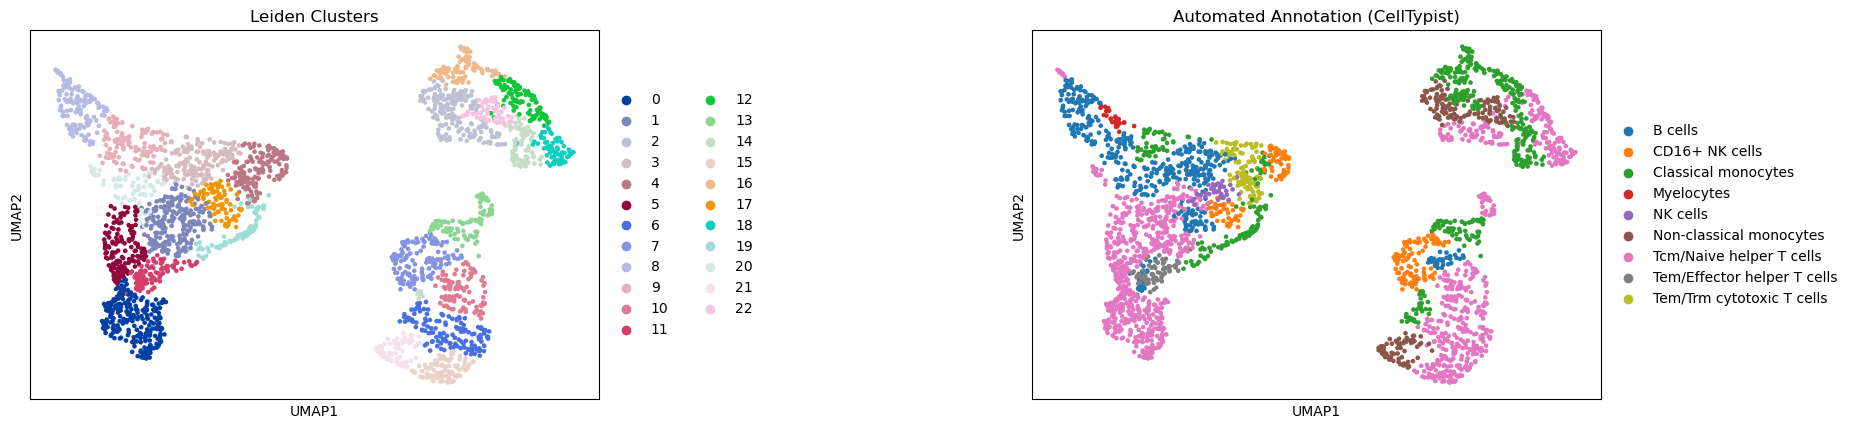

In [5]:
gene_ids = np.array(vocab(adata.var_names.tolist()), dtype=int)
loader = DataLoader(adata.obsm["X_binned"], batch_size=128, sampler=SequentialSampler(adata.obsm["X_binned"]))

cell_embeddings = []
with torch.no_grad():
    for batch in loader:
        batch_expr = batch.to(device)
        batch_genes = torch.tensor(gene_ids, dtype=torch.long).to(device).repeat(batch_expr.shape[0], 1)
        output = model(src=batch_genes, values=batch_expr, src_key_padding_mask=None)
        emb = output['cell_emb'] if 'cell_emb' in output else output['cls_output']
        cell_embeddings.append(emb.cpu().numpy())

adata.obsm["X_scGPT"] = np.concatenate(cell_embeddings, axis=0)

# Build neighborhood graph and cluster
sc.pp.neighbors(adata, use_rep="X_scGPT")
sc.tl.umap(adata)
sc.tl.leiden(adata, key_added="leiden", resolution=1.2)

# CellTypist Annotation
print("Running CellTypist Annotation...")
# models.download_models(force_update=False)  #usually auto handled
model_ct = models.Model.load(model='Immune_All_Low.pkl')

# CellTypist inherently requires log1p data (which we did in section 1)
predictions = celltypist.annotate(adata, model=model_ct, majority_voting=True)

# Transfer predictions: Use majority voting to clean up noisy single-cell predictions within scGPT clusters
adata.obs['celltypist_raw'] = predictions.predicted_labels['predicted_labels']
adata.obs['biological_identity'] = predictions.predicted_labels['majority_voting']

# Visualize the resulting annotations mapping over the scGPT latent space topology
sc.pl.umap(adata, color=['leiden', 'biological_identity'], title=['Leiden Clusters', 'Automated Annotation (CellTypist)'], wspace=0.6)

## 3. Targeted Perturbation Analysis
Testing the sensitivity of our identified cell types to the in-silico loss of a specific gene.

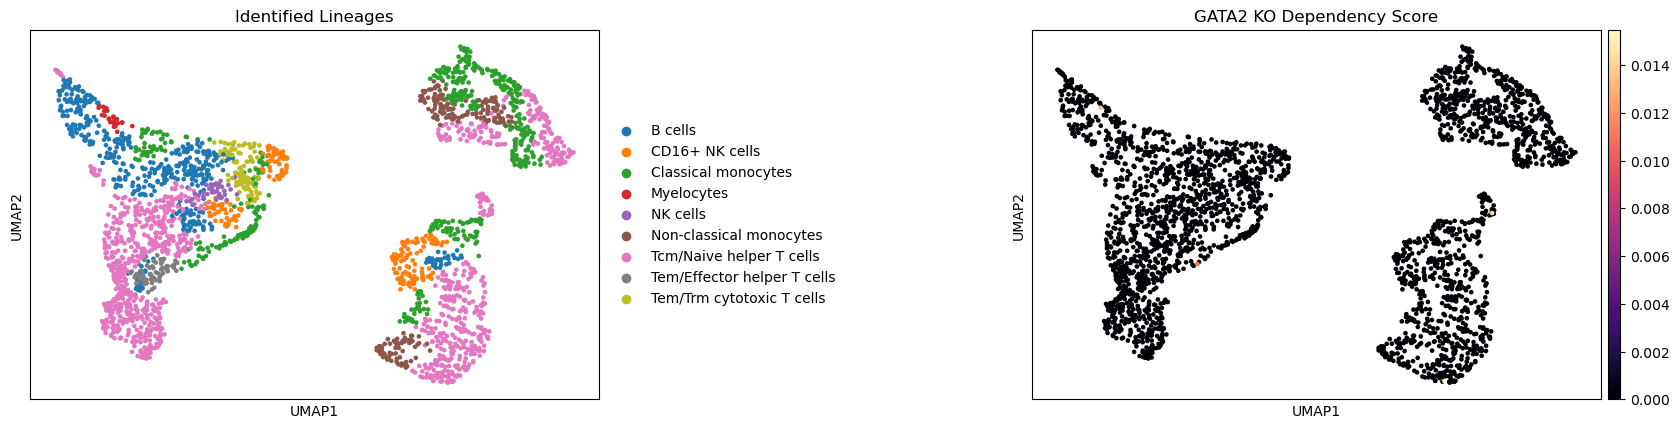

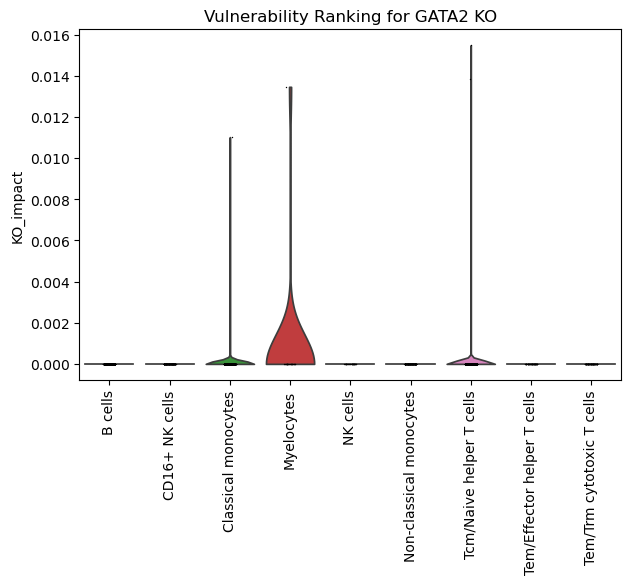

In [6]:
target_gene = "GATA2"

if target_gene in adata.var_names:
    gene_idx = list(adata.var_names).index(target_gene)
    
    # Create the perturbed input matrix
    X_perturbed = adata.obsm["X_binned"].copy()
    X_perturbed[:, gene_idx] = 0 
    
    p_loader = DataLoader(X_perturbed, batch_size=256, sampler=SequentialSampler(X_perturbed))
    p_embeddings = []
    
    with torch.no_grad():
        for batch in p_loader:
            batch_expr = batch.to(device)
            batch_genes = torch.tensor(gene_ids, dtype=torch.long).to(device).repeat(batch_expr.shape[0], 1)
            output = model(src=batch_genes, values=batch_expr, src_key_padding_mask=None)
            emb = output['cell_emb'] if 'cell_emb' in output else output['cls_output']
            p_embeddings.append(emb.cpu().numpy())
            
    adata.obsm["X_scGPT_KO"] = np.concatenate(p_embeddings, axis=0)
    
    # Calculate the 'L2' shift distance in latent space
    adata.obs["KO_impact"] = np.linalg.norm(adata.obsm["X_scGPT"] - adata.obsm["X_scGPT_KO"], axis=1)
    
    # 1. Visualization on UMAP
    sc.pl.umap(adata, color=["biological_identity", "KO_impact"], 
               title=["Identified Lineages", f"{target_gene} KO Dependency Score"], 
               cmap="magma", wspace=0.6)
    
    # 2. Ranking Sensitivity statistically (Bug Fixed)
    # sc.pl.violin does not accept 'title' argument directly in newer seaborn/scanpy versions.
    # We extract the matplotlib axes via show=False and set the title explicitly.
    ax = sc.pl.violin(adata, "KO_impact", groupby="biological_identity", rotation=90, show=False)
    
    if isinstance(ax, list):
        ax[0].set_title(f"Vulnerability Ranking for {target_gene} KO")
    else:
        ax.set_title(f"Vulnerability Ranking for {target_gene} KO")
        
    plt.show()
else:
    print(f"❌ Target gene {target_gene} not found in the highly variable gene list.")

Projecting GATA2 KO shifts onto UMAP topology...


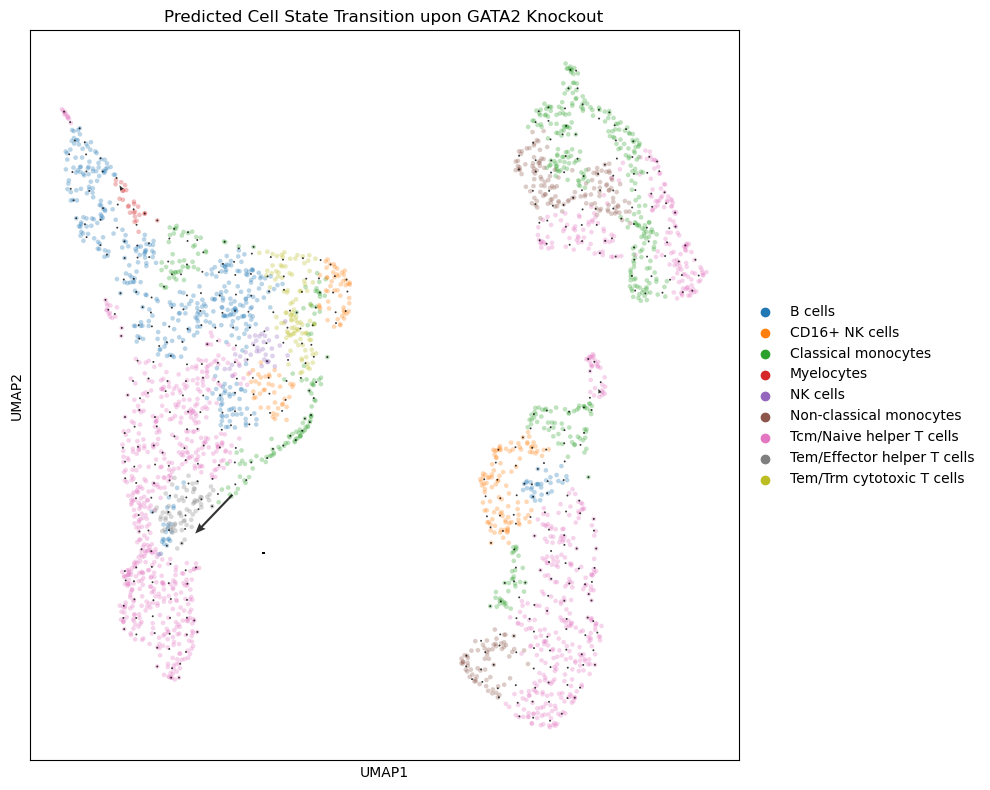

In [7]:
from sklearn.neighbors import NearestNeighbors
from scipy.special import softmax
import numpy as np

# 1. Calculate the high-dimensional perturbation shift for each cell
# This is the vector pointing from Wild Type to Knockout in scGPT latent space
delta_h = adata.obsm["X_scGPT_KO"] - adata.obsm["X_scGPT"]
X_wt = adata.obsm["X_scGPT"]
umap_coords = adata.obsm["X_umap"]

print(f"Projecting {target_gene} KO shifts onto UMAP topology...")

# 2. Build a local neighborhood graph to constrain valid transitions
k_neighbors = 30
nn = NearestNeighbors(n_neighbors=k_neighbors + 1).fit(X_wt)
distances, indices = nn.kneighbors(X_wt)

delta_umap = np.zeros_like(umap_coords)

# 3. Calculate Transition Probabilities for every cell
for i in range(adata.n_obs):
    # Get local neighbors (excluding the cell itself at index 0)
    neighbor_idx = indices[i, 1:] 
    
    # Vectors pointing from cell i to its neighbors in high-dimensional space
    diff_h = X_wt[neighbor_idx] - X_wt[i]
    
    # Calculate Cosine Similarity between the KO shift and neighbor directions
    shift_vector = delta_h[i]
    norm_shift = np.linalg.norm(shift_vector)
    
    if norm_shift == 0: 
        continue
        
    norm_diff = np.linalg.norm(diff_h, axis=1)
    valid_mask = norm_diff > 0 # Prevent division by zero
    
    cos_sim = np.zeros(k_neighbors)
    cos_sim[valid_mask] = np.dot(diff_h[valid_mask], shift_vector) / (norm_diff[valid_mask] * norm_shift)
    
    # Convert similarities to Transition Probabilities (Softmax with temperature scaling)
    temperature = 10.0 
    probs = softmax(cos_sim * temperature)
    
    # 4. Map the probabilities to vectors in the 2D UMAP space
    diff_umap = umap_coords[neighbor_idx] - umap_coords[i]
    delta_umap[i] = np.sum(diff_umap * probs[:, np.newaxis], axis=0)

# Store the resulting 2D arrows in adata
adata.obsm["X_umap_KO_shift"] = delta_umap

# 5. Visualization: Overlay vector field using a Matplotlib Quiver plot on a grid
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the baseline UMAP faintly in the background
sc.pl.umap(adata, color="biological_identity", ax=ax, show=False, alpha=0.3)

# Grid averaging to declutter the vector field (Standard practice for visual clarity)
grid_size = 40
u_x, u_y = umap_coords[:, 0], umap_coords[:, 1]
v_x, v_y = delta_umap[:, 0], delta_umap[:, 1]

x_bins = np.linspace(u_x.min(), u_x.max(), grid_size)
y_bins = np.linspace(u_y.min(), u_y.max(), grid_size)

grid_vx, grid_vy = np.zeros((grid_size-1, grid_size-1)), np.zeros((grid_size-1, grid_size-1))
grid_x, grid_y = np.zeros((grid_size-1, grid_size-1)), np.zeros((grid_size-1, grid_size-1))

for i in range(grid_size-1):
    for j in range(grid_size-1):
        mask = (u_x >= x_bins[i]) & (u_x < x_bins[i+1]) & \
               (u_y >= y_bins[j]) & (u_y < y_bins[j+1])
        if np.any(mask):
            grid_vx[j, i] = np.mean(v_x[mask])
            grid_vy[j, i] = np.mean(v_y[mask])
            grid_x[j, i] = np.mean(u_x[mask])
            grid_y[j, i] = np.mean(u_y[mask])

# Plot the directional arrows
ax.quiver(grid_x, grid_y, grid_vx, grid_vy, 
          angles='xy', scale_units='xy', scale=0.8, 
          color='black', width=0.003, headwidth=4, alpha=0.8)

ax.set_title(f"Predicted Cell State Transition upon {target_gene} Knockout")
plt.tight_layout()
plt.show()

Setting up baseline topology...
⚠️ Skipping B2M: Not present in the highly variable gene subset.
⚠️ Skipping CIITA: Not present in the highly variable gene subset.
⚠️ Skipping CD274: Not present in the highly variable gene subset.

🔬 Simulating Knockout for SPI1...


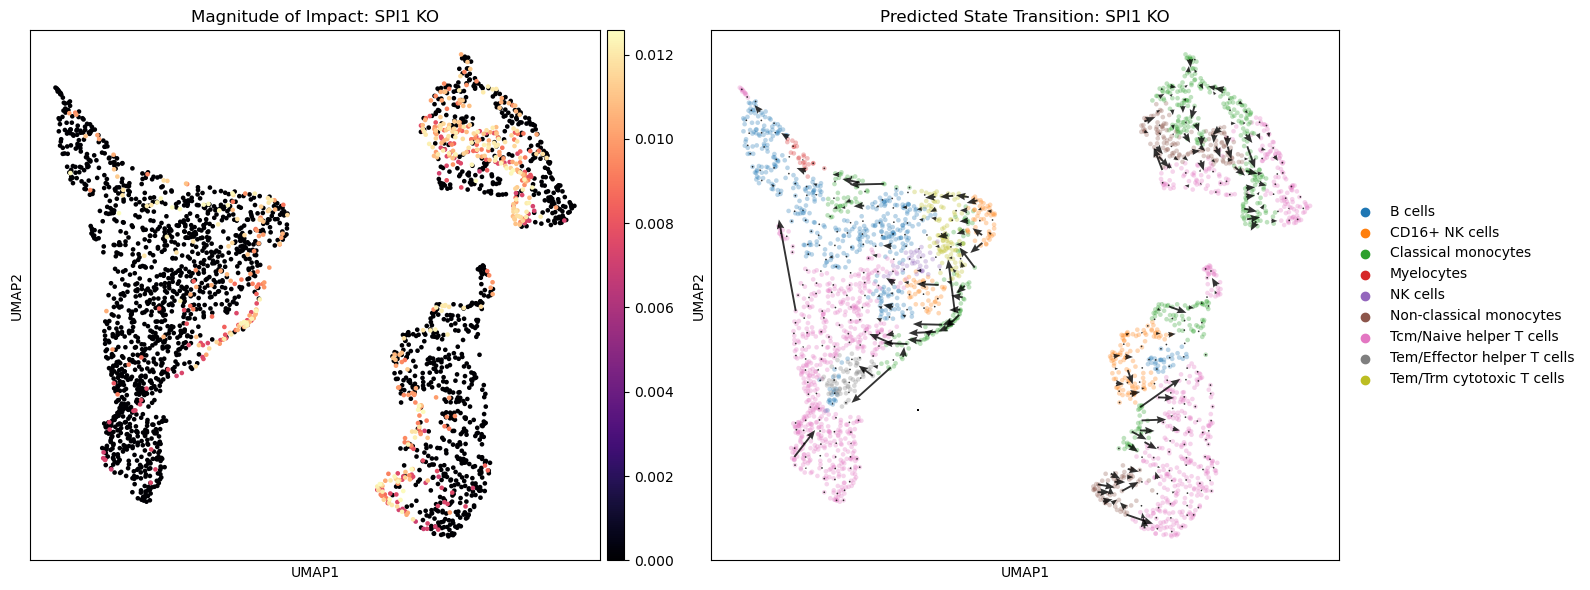

⚠️ Skipping STAT1: Not present in the highly variable gene subset.


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, SequentialSampler
from sklearn.neighbors import NearestNeighbors
from scipy.special import softmax
import scanpy as sc

# 1. Define the high-value target genes
target_genes = ["B2M", "CIITA", "CD274", "SPI1", "STAT1"]

# 2. Pre-compute baseline neighborhood (Only needs to happen once)
print("Setting up baseline topology...")
X_wt = adata.obsm["X_scGPT"]
umap_coords = adata.obsm["X_umap"]
k_neighbors = 30
nn = NearestNeighbors(n_neighbors=k_neighbors + 1).fit(X_wt)
distances, indices = nn.kneighbors(X_wt)

# Grid setup for vector field visual decluttering
grid_size = 40
u_x, u_y = umap_coords[:, 0], umap_coords[:, 1]
x_bins = np.linspace(u_x.min(), u_x.max(), grid_size)
y_bins = np.linspace(u_y.min(), u_y.max(), grid_size)

# 3. Iterate and Simulate
for gene in target_genes:
    # Handle cases where the gene was filtered out during the 1200 HVG subsetting
    if gene not in adata.var_names:
        print(f"⚠️ Skipping {gene}: Not present in the highly variable gene subset.")
        continue
        
    print(f"\n🔬 Simulating Knockout for {gene}...")
    gene_idx = list(adata.var_names).index(gene)
    
    # --- A. Digital Knockout & Latent Inference ---
    X_perturbed = adata.obsm["X_binned"].copy()
    X_perturbed[:, gene_idx] = 0 
    
    p_loader = DataLoader(X_perturbed, batch_size=256, sampler=SequentialSampler(X_perturbed))
    p_embeddings = []
    
    with torch.no_grad():
        for batch in p_loader:
            batch_expr = batch.to(device)
            batch_genes = torch.tensor(gene_ids, dtype=torch.long).to(device).repeat(batch_expr.shape[0], 1)
            output = model(src=batch_genes, values=batch_expr, src_key_padding_mask=None)
            emb = output['cell_emb'] if 'cell_emb' in output else output['cls_output']
            p_embeddings.append(emb.cpu().numpy())
            
    X_ko = np.concatenate(p_embeddings, axis=0)
    
    # Save the L2 distance impact score
    impact_key = f"{gene}_KO_impact"
    adata.obs[impact_key] = np.linalg.norm(X_wt - X_ko, axis=1)
    
    # --- B. Vector Field Projection ---
    delta_h = X_ko - X_wt
    delta_umap = np.zeros_like(umap_coords)
    
    for i in range(adata.n_obs):
        neighbor_idx = indices[i, 1:] 
        diff_h = X_wt[neighbor_idx] - X_wt[i]
        
        shift_vector = delta_h[i]
        norm_shift = np.linalg.norm(shift_vector)
        if norm_shift == 0: continue
            
        norm_diff = np.linalg.norm(diff_h, axis=1)
        valid_mask = norm_diff > 0 
        
        # Cosine similarity between KO shift and baseline neighbor directions
        cos_sim = np.zeros(k_neighbors)
        cos_sim[valid_mask] = np.dot(diff_h[valid_mask], shift_vector) / (norm_diff[valid_mask] * norm_shift)
        
        # Softmax to probabilities
        probs = softmax(cos_sim * 10.0)
        diff_umap = umap_coords[neighbor_idx] - umap_coords[i]
        delta_umap[i] = np.sum(diff_umap * probs[:, np.newaxis], axis=0)

    # --- C. Dual Visualization ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Magnitude (Heatmap)
    sc.pl.umap(adata, color=impact_key, cmap="magma", ax=ax1, show=False)
    ax1.set_title(f"Magnitude of Impact: {gene} KO")
    
    # Plot 2: Vector Field
    sc.pl.umap(adata, color="biological_identity", ax=ax2, show=False, alpha=0.3)
    v_x, v_y = delta_umap[:, 0], delta_umap[:, 1]
    
    grid_vx, grid_vy = np.zeros((grid_size-1, grid_size-1)), np.zeros((grid_size-1, grid_size-1))
    grid_x, grid_y = np.zeros((grid_size-1, grid_size-1)), np.zeros((grid_size-1, grid_size-1))

    # Average vectors over the grid
    for i in range(grid_size-1):
        for j in range(grid_size-1):
            mask = (u_x >= x_bins[i]) & (u_x < x_bins[i+1]) & (u_y >= y_bins[j]) & (u_y < y_bins[j+1])
            if np.any(mask):
                grid_vx[j, i], grid_vy[j, i] = np.mean(v_x[mask]), np.mean(v_y[mask])
                grid_x[j, i], grid_y[j, i] = np.mean(u_x[mask]), np.mean(u_y[mask])

    # Draw the arrows
    ax2.quiver(grid_x, grid_y, grid_vx, grid_vy, angles='xy', scale_units='xy', scale=0.8, color='black', width=0.003, headwidth=4, alpha=0.8)
    ax2.set_title(f"Predicted State Transition: {gene} KO")
    
    plt.tight_layout()
    plt.show()